Configuración e imports

In [37]:
from pathlib import Path
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf

In [38]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

DATA_PATH    = Path("../../data/features/hotel_ttoo")
METRICS_PATH = Path("../../models/metrics")
METRICS_PATH.mkdir(parents=True, exist_ok=True)

Carga de datos

In [39]:
files = list(DATA_PATH.glob("*.parquet"))
hotel_datasets = {}
for file in files:
    hotel_name = file.stem          
    df = pd.read_parquet(file)
    hotel_datasets[hotel_name] = df

print("Hoteles cargados:", list(hotel_datasets.keys()))

Hoteles cargados: ['HOTEL_1', 'HOTEL_2', 'HOTEL_3']


Validación de datos

In [40]:
# ── Inspección básica ─────────────────────────────────────────────────────────
for hotel, df in hotel_datasets.items():
    print(f"\n--- {hotel} ---")
    print("Filas:", len(df))
    print("Valores nulos:")
    print(df.isna().sum())
    print("Duplicados:", df.duplicated().sum())


--- HOTEL_1 ---
Filas: 1024
Valores nulos:
fecha         0
hotel         0
ocup_total    0
is_weekend    0
season        0
rn_AL         0
rn_AV         0
rn_B          0
rn_C          0
rn_EA         0
rn_EX         0
rn_H          0
rn_J          0
rn_K          0
rn_L          0
rn_O          0
rn_T          0
rn_TH         0
rn_TR         0
rn_WEB        0
rn_WEL        0
dtype: int64
Duplicados: 0

--- HOTEL_2 ---
Filas: 929
Valores nulos:
fecha         0
hotel         0
ocup_total    0
is_weekend    0
season        0
rn_AL         0
rn_AV         0
rn_B          0
rn_C          0
rn_EA         0
rn_EX         0
rn_H          0
rn_J          0
rn_K          0
rn_L          0
rn_O          0
rn_T          0
rn_TH         0
rn_TR         0
rn_WEB        0
rn_WEL        0
dtype: int64
Duplicados: 0

--- HOTEL_3 ---
Filas: 1085
Valores nulos:
fecha         0
hotel         0
ocup_total    0
is_weekend    0
season        0
rn_AL         0
rn_AV         0
rn_B          0
rn_C          0

Preparación temporal

In [41]:
for hotel, df in hotel_datasets.items():
    df["fecha"] = pd.to_datetime(df["fecha"])
    df = df.sort_values("fecha").set_index("fecha")
    hotel_datasets[hotel] = df

Visualización de la serie temporal

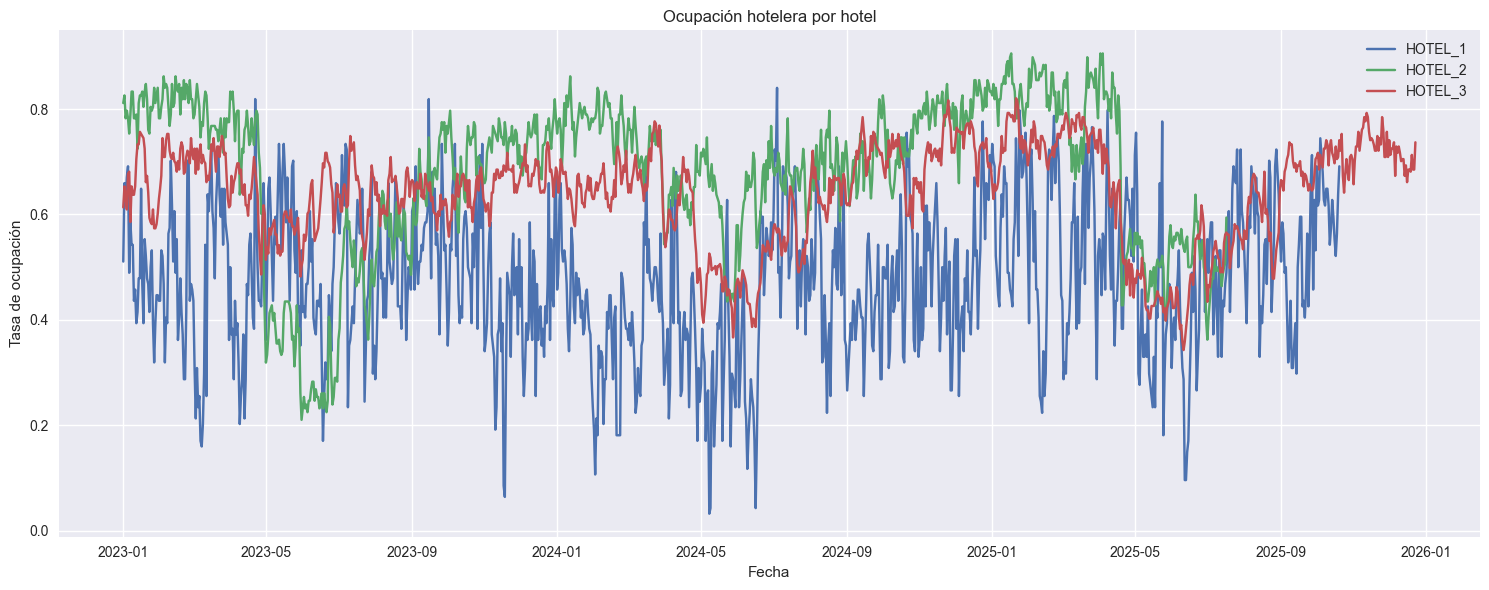

In [42]:
plt.figure(figsize=(15, 6))
for hotel, df in hotel_datasets.items():
    plt.plot(df.index, df["ocup_total"], label=hotel)
plt.title("Ocupación hotelera por hotel")
plt.xlabel("Fecha")
plt.ylabel("Tasa de ocupación")
plt.legend()
plt.tight_layout()
plt.show()

Train / Test Split temporal

In [43]:
splits = {}
for hotel, df in hotel_datasets.items():
    df = df.sort_index()
    split_idx = int(len(df) * 0.8)
    train = df.iloc[:split_idx]
    test  = df.iloc[split_idx:]
    splits[hotel] = (train, test)

print("Split realizado correctamente.")

Split realizado correctamente.


Función de métricas

In [44]:
def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    epsilon = 1e-8
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100
    return mae, rmse, mape

Baseline 1 — Naive Forecast

In [45]:
results = []
for hotel, (train, test) in splits.items():
    test = test.copy()
    last_train_value      = train["ocup_total"].iloc[-1]
    naive_forecast        = test["ocup_total"].shift(1)
    naive_forecast.iloc[0] = last_train_value
    test["naive_forecast"] = naive_forecast

    mae, rmse, mape = compute_metrics(test["ocup_total"], test["naive_forecast"])
    results.append({"hotel": hotel, "modelo": "Naive",
                    "MAE": mae, "RMSE": rmse, "MAPE": mape})

results_df = pd.DataFrame(results)
results_df

,hotel,modelo,MAE,RMSE,MAPE
0,HOTEL_1,Naive,0.0847,0.1117,20.1964
1,HOTEL_2,Naive,0.0295,0.0410,4.7219
2,HOTEL_3,Naive,0.0205,0.0264,3.4347


Baseline 2 — Seasonal Naive

In [46]:
seasonal_results = []
for hotel, (train, test) in splits.items():
    test = test.copy()
    seasonal_forecast          = test["ocup_total"].shift(7)
    seasonal_forecast.iloc[:7] = train["ocup_total"].iloc[-7:].values
    test["seasonal_forecast"]  = seasonal_forecast

    mae, rmse, mape = compute_metrics(test["ocup_total"], test["seasonal_forecast"])
    seasonal_results.append({"hotel": hotel, "modelo": "Seasonal Naive",
                              "MAE": mae, "RMSE": rmse, "MAPE": mape})

seasonal_df = pd.DataFrame(seasonal_results)

Baseline 3 — Moving Average

In [47]:
ma_results = []
window = 7
for hotel, (train, test) in splits.items():
    test = test.copy()
    full_series  = pd.concat([train["ocup_total"], test["ocup_total"]])
    rolling_mean = full_series.rolling(window=window).mean()
    ma_forecast  = rolling_mean.loc[test.index]
    test["ma_forecast"] = ma_forecast

    mae, rmse, mape = compute_metrics(test["ocup_total"], test["ma_forecast"])
    ma_results.append({"hotel": hotel, "modelo": "Moving Average (7)",
                       "MAE": mae, "RMSE": rmse, "MAPE": mape})

ma_df = pd.DataFrame(ma_results)

Tabla comparativa de modelos

In [48]:
all_results = pd.concat([results_df, seasonal_df, ma_df], ignore_index=True)
all_results = all_results.sort_values(["hotel", "RMSE"])
all_results

,hotel,modelo,MAE,RMSE,MAPE
6,HOTEL_1,Moving Average (7),0.0843,0.1045,21.0598
0,HOTEL_1,Naive,0.0847,0.1117,20.1964
3,HOTEL_1,Seasonal Naive,0.1303,0.1649,32.3558
1,HOTEL_2,Naive,0.0295,0.0410,4.7219
7,HOTEL_2,Moving Average (7),0.0357,0.0516,6.0115
4,HOTEL_2,Seasonal Naive,0.0655,0.0941,11.1303
2,HOTEL_3,Naive,0.0205,0.0264,3.4347
8,HOTEL_3,Moving Average (7),0.0261,0.0332,4.5186
5,HOTEL_3,Seasonal Naive,0.0481,0.0631,8.2437


Ranking global de modelos

In [49]:
summary = (
    all_results
    .groupby("modelo")[["MAE", "RMSE", "MAPE"]]
    .mean()
    .sort_values("RMSE")
)
summary

,MAE,RMSE,MAPE
modelo,,,
Naive,0.0449,0.0597,9.4510
Moving Average (7),0.0487,0.0631,10.5300
Seasonal Naive,0.0813,0.1074,17.2433


Visualización de comparación de métricas

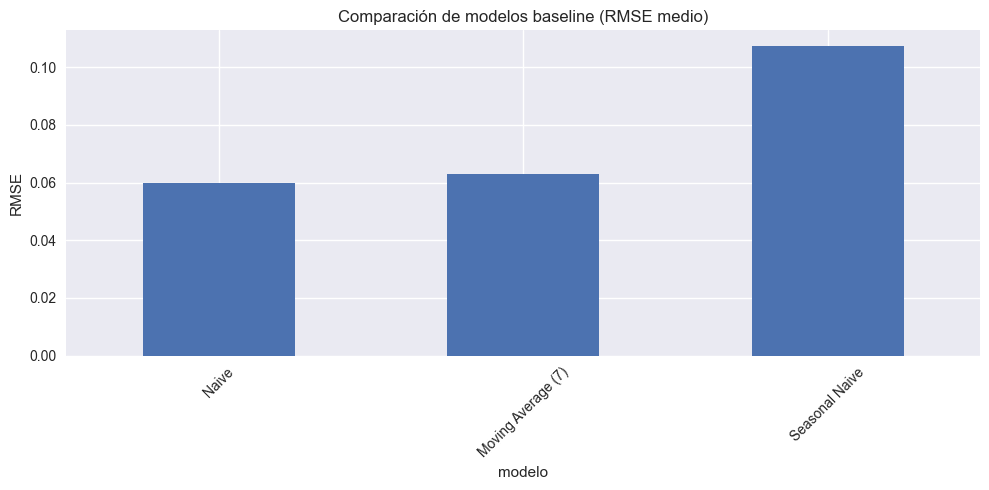

In [50]:
plt.figure(figsize=(10, 5))
summary["RMSE"].plot(kind="bar")
plt.title("Comparación de modelos baseline (RMSE medio)")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Comparación visual de modelos

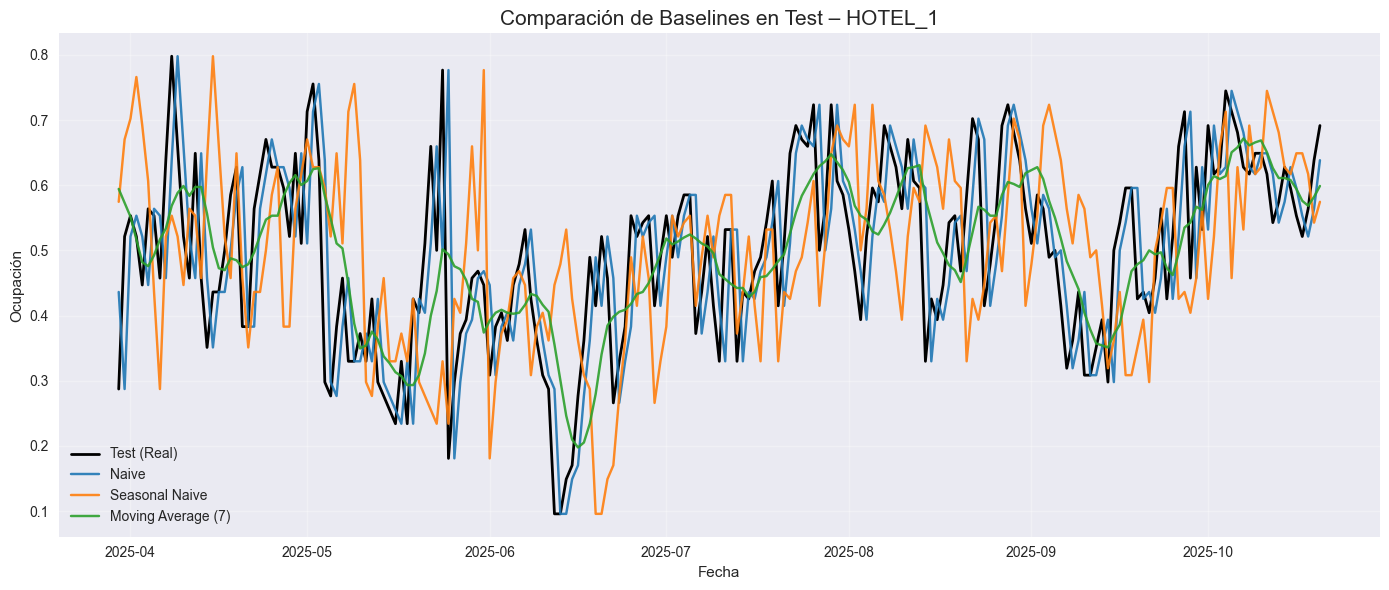

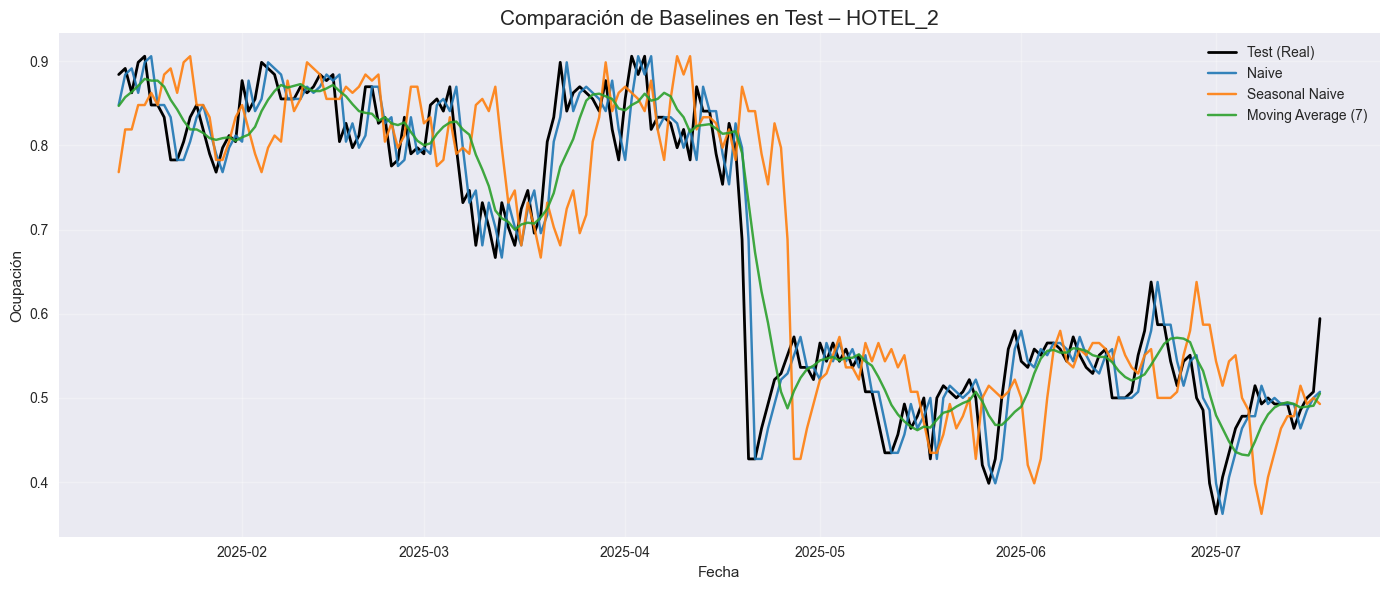

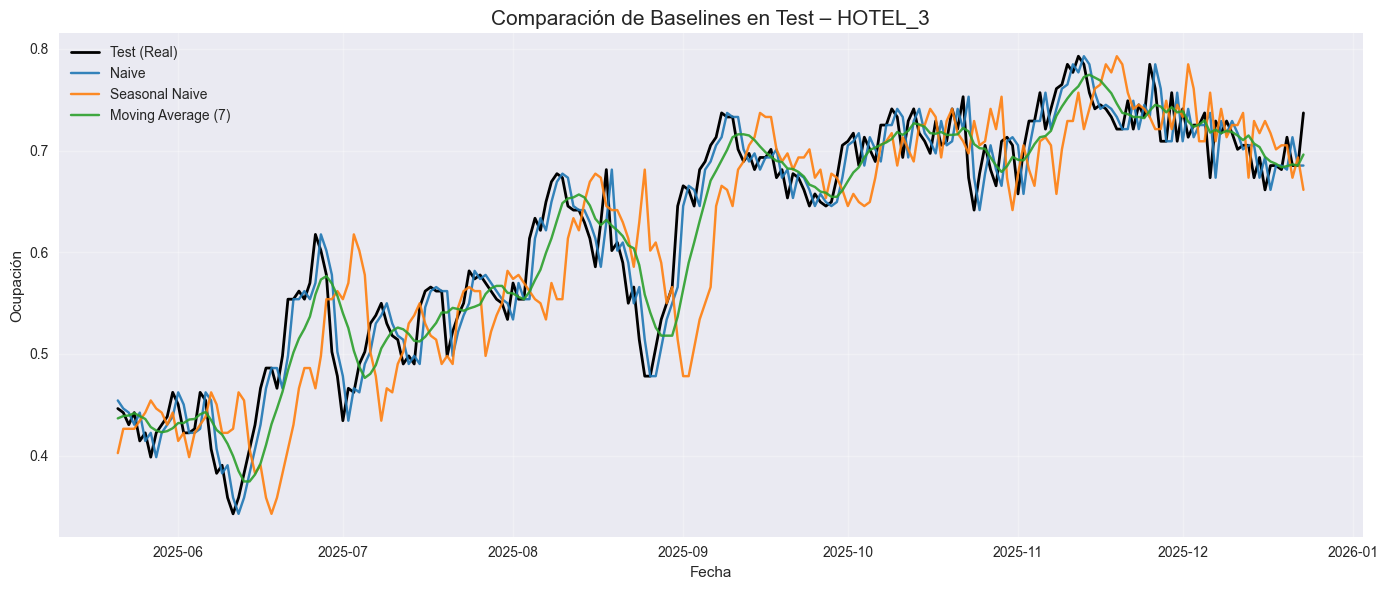

In [51]:
for hotel, (train, test) in splits.items():
    test = test.copy()

    last_train = train["ocup_total"].iloc[-1]
    naive      = test["ocup_total"].shift(1)
    naive.iloc[0] = last_train

    seasonal          = test["ocup_total"].shift(7)
    seasonal.iloc[:7] = train["ocup_total"].iloc[-7:].values

    full_series = pd.concat([train["ocup_total"], test["ocup_total"]])
    ma = full_series.rolling(7).mean().loc[test.index]

    plt.figure(figsize=(14, 6))
    plt.plot(test.index, test["ocup_total"], label="Test (Real)",
             color="black", linewidth=2)
    plt.plot(test.index, naive,    label="Naive",              color="#1f77b4", alpha=0.9)
    plt.plot(test.index, seasonal, label="Seasonal Naive",     color="#ff7f0e", alpha=0.9)
    plt.plot(test.index, ma,       label="Moving Average (7)", color="#2ca02c", alpha=0.9)
    plt.title(f"Comparación de Baselines en Test – {hotel}", fontsize=15)
    plt.xlabel("Fecha")
    plt.ylabel("Ocupación")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

Gráfica de autocorrelación (ACF)

<Figure size 1200x400 with 0 Axes>

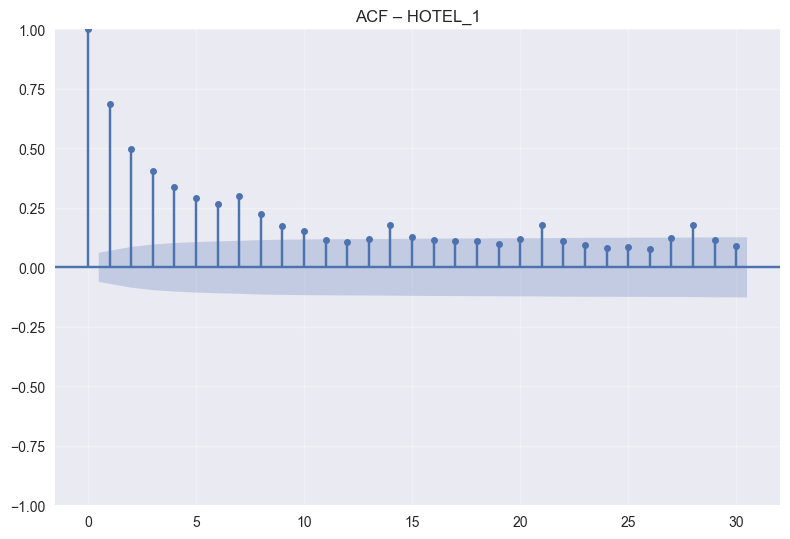

<Figure size 1200x400 with 0 Axes>

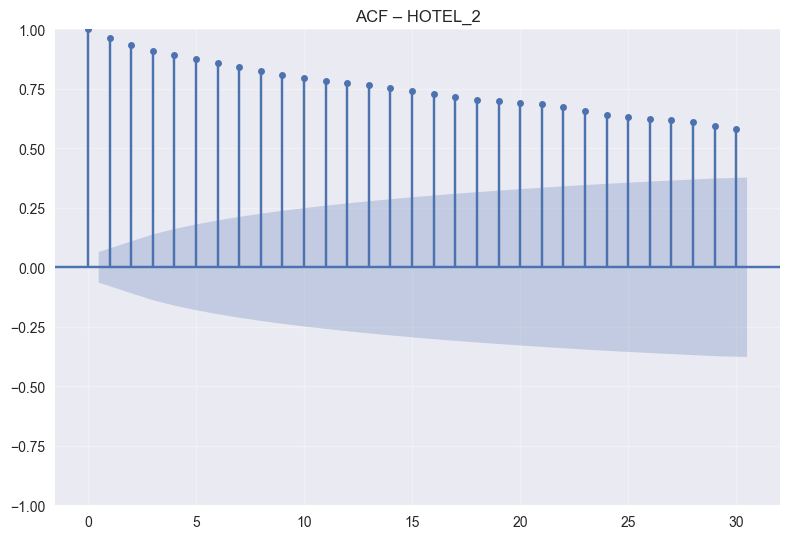

<Figure size 1200x400 with 0 Axes>

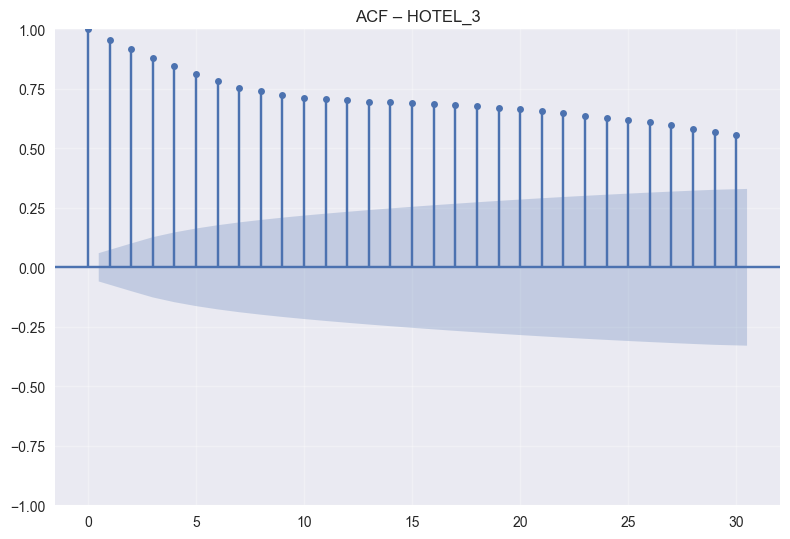

In [52]:
for hotel, df in hotel_datasets.items():
    plt.figure(figsize=(12, 4))
    plot_acf(df["ocup_total"], lags=30)
    plt.title(f"ACF – {hotel}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Gráfica de distribución del error por baseline

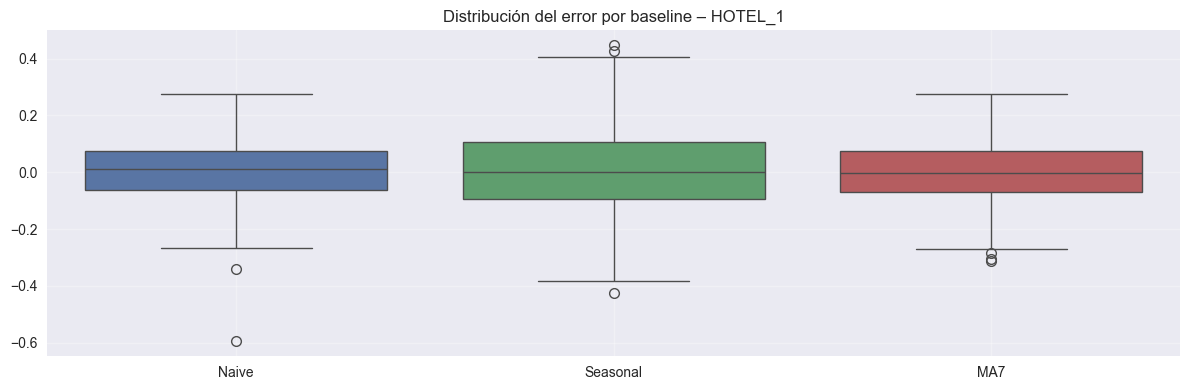

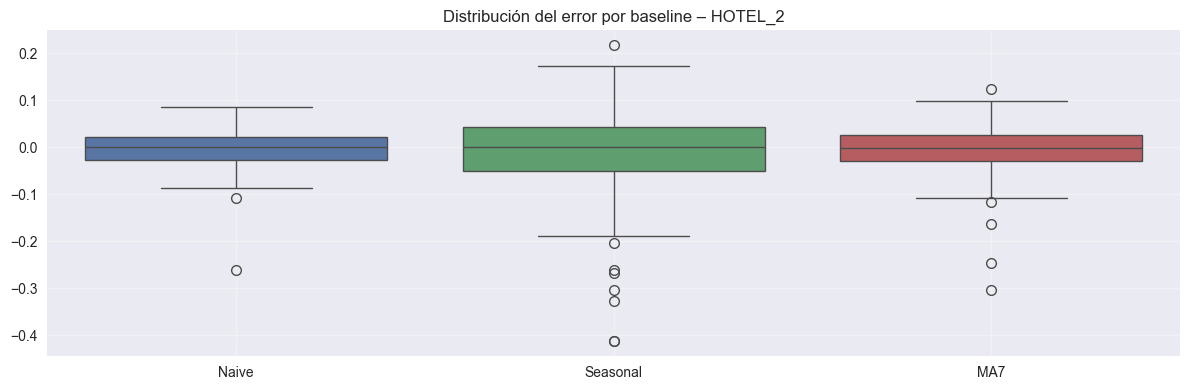

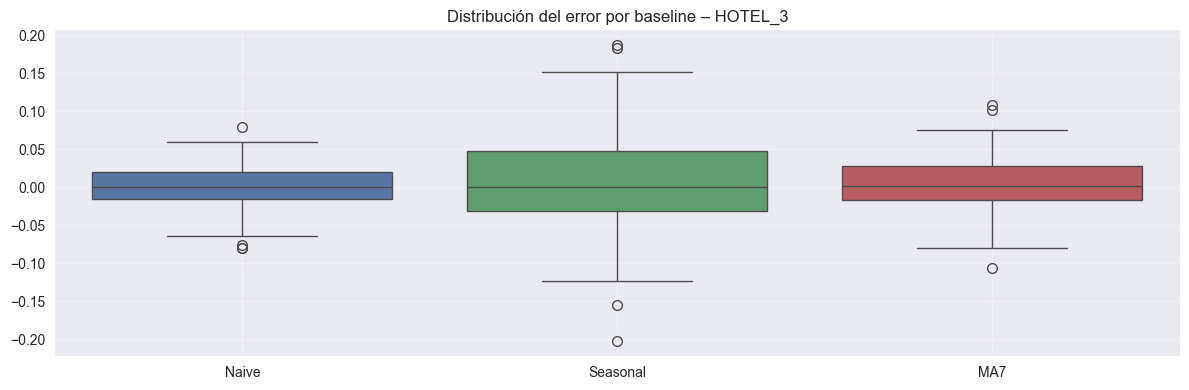

In [53]:
for hotel, (train, test) in splits.items():
    test = test.copy()

    last_train = train["ocup_total"].iloc[-1]
    naive      = test["ocup_total"].shift(1)
    naive.iloc[0] = last_train

    seasonal          = test["ocup_total"].shift(7)
    seasonal.iloc[:7] = train["ocup_total"].iloc[-7:].values

    full = pd.concat([train["ocup_total"], test["ocup_total"]])
    ma   = full.rolling(7).mean().loc[test.index]

    plt.figure(figsize=(12, 4))
    sns.boxplot(data=pd.DataFrame({
        "Naive":    test["ocup_total"] - naive,
        "Seasonal": test["ocup_total"] - seasonal,
        "MA7":      test["ocup_total"] - ma
    }))
    plt.title(f"Distribución del error por baseline – {hotel}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Guardar métricas

In [54]:
metrics_file = METRICS_PATH / "baseline_comparison.csv"
all_results.to_csv(metrics_file, index=False)
print("Métricas guardadas en:", metrics_file)

Métricas guardadas en: ..\..\models\metrics\baseline_comparison.csv


# Conclusiones del análisis baseline

En este notebook se han evaluado tres modelos baseline para la predicción de la ocupación hotelera —Naive, Seasonal Naive y Moving Average (7)— con el objetivo de establecer un punto de referencia sencillo frente al cual comparar los modelos avanzados desarrollados posteriormente.

Los resultados muestran un comportamiento diferenciado según el hotel, lo que confirma que cada establecimiento presenta dinámicas propias de demanda.

# Hotel 1

En Hotel 1 el modelo Moving Average (7) obtiene el mejor rendimiento, con un RMSE = 0.1045, ligeramente mejor que Naive (RMSE = 0.1117).
El Seasonal Naive es claramente inferior, lo que indica que la estacionalidad semanal no explica de manera consistente la ocupación diaria en este hotel.

## Interpretación

Hotel 1 presenta mayor variabilidad y menos estabilidad diaria, por lo que un suavizado de corto plazo (MA7) captura mejor la tendencia reciente que la dependencia directa del día anterior o de la semana anterior.

# Hotel 2

En este hotel el modelo Naive es el más competitivo, alcanzando un RMSE = 0.0410 y un MAPE del 4.72%.
Los modelos Moving Average y Seasonal Naive muestran errores más altos.

## Interpretación

La serie de ocupación de Hotel 2 es muy estable y con alta persistencia temporal: el valor del día anterior es un excelente predictor del día siguiente. Esto es consistente con hoteles que dependen fuertemente de un mismo perfil de demanda o de touroperadores dominantes.

# Hotel 3

Nuevamente, Naive es el mejor baseline, con un RMSE = 0.0264 y un MAPE del 3.43%.
Los modelos Seasonal Naive y MA7 presentan un rendimiento inferior, aunque cercano.

## Interpretación

La ocupación de Hotel 3 muestra un patrón muy regular, con cambios suaves y un comportamiento más estable. En estos casos, el valor del día previo aporta prácticamente toda la información relevante.

# Conclusión general

- Naive es el mejor baseline en dos de los tres hoteles (Hotel 2 y Hotel 3), lo que confirma la fuerte autocorrelación diaria típica en series de ocupación hotelera.
- MA(7) destaca en Hotel 1, donde la ocupación es más volátil y se beneficia del suavizado de corto plazo.
- Seasonal Naive es el menos competitivo en todos los casos, indicando que la estacionalidad semanal no es el principal patrón temporal en estas series.
- En conjunto, estos resultados proporcionan un punto de referencia claro y realista para evaluar modelos más complejos.

Estos baselines serán fundamentales para evaluar los modelos avanzados (SARIMAX, Random Forest, XGBoost) generados posteriormente, ya que permiten cuantificar si realmente aportan mejoras predictivas o si la ocupación diaria de cada hotel puede explicarse mediante dinámicas simples.